# 06 · Hands on: fine-tune DETR on your own dataset

> **Paper:** §3.2 (auxiliary decoding losses), §4 (training details) · **Code:** [`main.py`](../main.py), [`engine.py`](../engine.py)

Time to actually train. We'll fine-tune the COCO-pretrained DETR on a **synthetic shapes dataset** — small enough to train in ~2 minutes on a laptop, real enough to exercise every piece of machinery from notebooks `02`–`05`.

**The task:** find coloured shapes and classify them by colour (`red` / `green` / `blue`). Shape (rectangle vs ellipse) is a deliberate distractor — the model must learn to ignore it.

> **Why fine-tune instead of training from scratch?** DETR is notoriously slow to converge — the paper trains for **300–500 epochs** on 16 V100 GPUs (§4). From scratch on a laptop you'd wait days. Starting from COCO weights, the backbone and encoder already know what "an object" looks like; only the heads need to learn your classes. This is the same transfer-learning idea as freezing a pretrained CNN for classification.

In [1]:
%matplotlib inline
import time, random
import numpy as np, torch, matplotlib.pyplot as plt
from torch import nn
from PIL import Image, ImageDraw
from detr_utils import *   # noqa: F403
from models.matcher import HungarianMatcher
from models.detr import SetCriterion

device = get_device()
torch.manual_seed(0)
print("device:", device)

device: mps


## 1. A synthetic dataset

Generated on the fly, so there is nothing to download. Each image has 1–3 shapes; the **class is the colour**, and the box is exactly known.

Note the target format — it must match what `SetCriterion` expects (see the docstrings in [`models/detr.py`](../models/detr.py#L143)):
- `boxes`: `(n, 4)` float, **normalized `(cx, cy, w, h)`** in `[0,1]`
- `labels`: `(n,)` int64, class ids starting at 0

In [2]:
IMG = 320
PALETTE = [(220, 40, 40), (40, 170, 60), (50, 90, 220)]
NAMES = ["red", "green", "blue"]
NUM_CLASSES = 3                     # -> class_embed outputs 3 + 1 = 4 logits

IMAGENET_MEAN = torch.tensor([.485, .456, .406])[:, None, None]
IMAGENET_STD = torch.tensor([.229, .224, .225])[:, None, None]


def make_sample(rng):
    """One synthetic image + its ground-truth target dict."""
    im = Image.new("RGB", (IMG, IMG), (245, 245, 240))
    d = ImageDraw.Draw(im)
    boxes, labels = [], []
    for _ in range(rng.randint(1, 3)):
        w, h = rng.randint(60, 120), rng.randint(60, 120)
        x0, y0 = rng.randint(0, IMG - w), rng.randint(0, IMG - h)
        k = rng.randint(0, 2)                              # class = colour
        shape = "ellipse" if rng.random() < .5 else "rectangle"   # distractor
        getattr(d, shape)([x0, y0, x0 + w, y0 + h], fill=PALETTE[k])
        boxes.append([(x0 + w/2)/IMG, (y0 + h/2)/IMG, w/IMG, h/IMG])   # cxcywh, normalized
        labels.append(k)
    x = torch.from_numpy(np.array(im)).permute(2, 0, 1).float() / 255.   # (3, 320, 320)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x, im, {"boxes": torch.tensor(boxes, dtype=torch.float32),
                   "labels": torch.tensor(labels, dtype=torch.int64)}


def make_batch(bs, rng):
    out = [make_sample(rng) for _ in range(bs)]
    return torch.stack([o[0] for o in out]), [o[1] for o in out], [o[2] for o in out]


rng = random.Random(0)
x, pils, targets = make_batch(4, rng)
print("images :", tuple(x.shape))
print("target0:", {k: tuple(v.shape) for k, v in targets[0].items()})
print("labels :", targets[0]["labels"].tolist(),
      "->", [NAMES[i] for i in targets[0]["labels"].tolist()])

images : (4, 3, 320, 320)
target0: {'boxes': (2, 4), 'labels': (2,)}
labels : [1, 1] -> ['green', 'green']


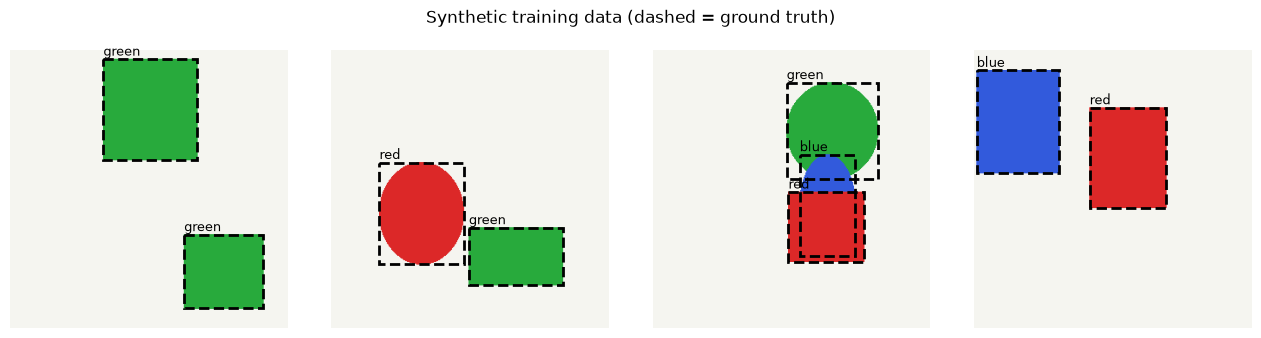

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, pil, t in zip(axes, pils, targets):
    ax.imshow(pil)
    for b, l in zip(t["boxes"], t["labels"]):
        cx, cy, w, h = (b * IMG).tolist()
        ax.add_patch(plt.Rectangle((cx-w/2, cy-h/2), w, h, fill=False, color="k", lw=2, ls="--"))
        ax.text(cx-w/2, cy-h/2-4, NAMES[l], fontsize=9)
    ax.axis("off")
plt.suptitle("Synthetic training data (dashed = ground truth)")
plt.tight_layout(); plt.show()

## 2. Model surgery

Three changes turn a COCO detector into a 3-class shape detector.

In [4]:
model = load_pretrained_detr(device="cpu", aux_loss=True)
print("BEFORE:", model.class_embed, "  num_queries =", model.num_queries)

# (1) new classification head: 91+1 -> 3+1 classes. Randomly initialised.
model.class_embed = nn.Linear(model.transformer.d_model, NUM_CLASSES + 1)

# (2) 100 query slots is overkill for 1-3 objects, and makes the ∅ imbalance worse.
#     Keep the first 20 PRETRAINED queries rather than starting from scratch.
NQ = 20
model.query_embed = nn.Embedding.from_pretrained(model.query_embed.weight[:NQ].clone(),
                                                 freeze=False)
model.num_queries = NQ

# (3) freeze the CNN backbone -- ImageNet/COCO features are already good, and this
#     is the bulk of the compute.
for p in model.backbone.parameters():
    p.requires_grad_(False)

model.to(device)
print("AFTER :", model.class_embed, "  num_queries =", model.num_queries)
tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\ntrainable: {tr/1e6:.1f}M / {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


BEFORE: Linear(in_features=256, out_features=92, bias=True)   num_queries = 100
AFTER : Linear(in_features=256, out_features=4, bias=True)   num_queries = 20

trainable: 18.0M / 41.5M


Note `bbox_embed` is **kept**, not replaced — "where is the object" is task-independent, so those pretrained weights transfer directly. Only "which class is it" had to be relearned.

## 3. Loss, with auxiliary decoding losses

`aux_loss=True` makes the model return predictions from **every** decoder layer, so the loss is applied 6 times. The paper found this *"helpful to... help the model output the correct number of objects"* (§3.2) — and we'll verify that claim at the end.

In [5]:
matcher = HungarianMatcher(cost_class=1, cost_bbox=5, cost_giou=2)

weight_dict = {"loss_ce": 1, "loss_bbox": 5, "loss_giou": 2}
# the same three terms after each of the first 5 decoder layers
weight_dict.update({f"{k}_{i}": v for i in range(5) for k, v in list(weight_dict.items())})

criterion = SetCriterion(NUM_CLASSES, matcher, weight_dict,
                         eos_coef=0.1,
                         losses=["labels", "boxes", "cardinality"]).to(device)
print(f"{len(weight_dict)} weighted loss terms = 3 final + 15 auxiliary")
print(sorted(weight_dict)[:6], "...")

18 weighted loss terms = 3 final + 15 auxiliary
['loss_bbox', 'loss_bbox_0', 'loss_bbox_1', 'loss_bbox_2', 'loss_bbox_3', 'loss_bbox_4'] ...


### Optimizer: different learning rates for different parts

`class_embed` is brand new (random weights) while the transformer is pretrained. Giving the new head a **10× higher LR** lets it catch up without wrecking the pretrained layers — this made a large difference in practice.

In [6]:
head, rest = [], []
for n, p in model.named_parameters():
    if not p.requires_grad:
        continue
    (head if ("class_embed" in n or "bbox_embed" in n) else rest).append(p)

optimizer = torch.optim.AdamW([{"params": head, "lr": 1e-3},     # new heads
                               {"params": rest, "lr": 1e-4}],    # pretrained transformer
                              weight_decay=1e-4)
print(f"heads: {sum(p.numel() for p in head)/1e3:6.0f}K params @ lr 1e-3")
print(f"rest : {sum(p.numel() for p in rest)/1e6:6.1f}M params @ lr 1e-4")

heads:    134K params @ lr 1e-3
rest :   17.9M params @ lr 1e-4


## 4. Predictions *before* training (the control)

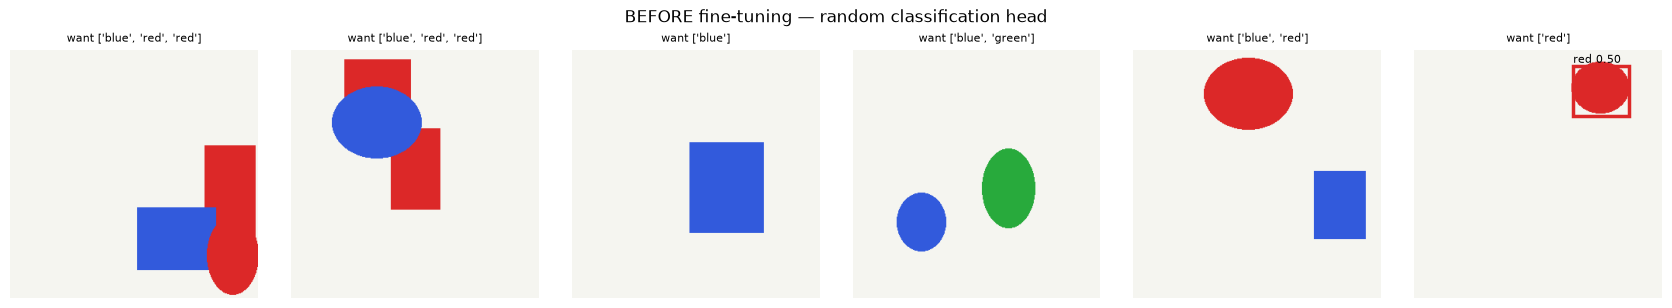

In [7]:
eval_rng = random.Random(999)
eval_x, eval_pils, eval_t = make_batch(6, eval_rng)


@torch.no_grad()
def predict(m, xb, thresh=0.5):
    m.eval()
    probs = m(xb.to(device))["pred_logits"].softmax(-1).cpu()   # (B, NQ, 4)
    boxes = m(xb.to(device))["pred_boxes"].cpu()                # (B, NQ, 4)
    keep = (probs.argmax(-1) != NUM_CLASSES) & (probs[..., :-1].max(-1).values > thresh)
    return probs, boxes, keep


def show(m, title, thresh=0.5):
    probs, boxes, keep = predict(m, eval_x, thresh)
    fig, axes = plt.subplots(1, 6, figsize=(17, 3.1))
    for i, (ax, pil, t) in enumerate(zip(axes, eval_pils, eval_t)):
        ax.imshow(pil); ax.axis("off")
        for q in keep[i].nonzero().flatten().tolist():
            cx, cy, w, h = (boxes[i, q] * IMG).tolist()
            cls = probs[i, q, :-1].argmax().item()
            col = np.array(PALETTE[cls]) / 255.
            ax.add_patch(plt.Rectangle((cx-w/2, cy-h/2), w, h, fill=False, color=col, lw=2.5))
            ax.text(cx-w/2, cy-h/2-4, f"{NAMES[cls]} {probs[i,q,:-1].max():.2f}",
                    fontsize=8, color="k")
        ax.set_title(f"want {sorted(NAMES[c] for c in t['labels'].tolist())}", fontsize=8)
    plt.suptitle(title); plt.tight_layout(); plt.show()
    return probs, boxes, keep


_ = show(model, "BEFORE fine-tuning — random classification head")

Nonsense, as expected: the head is random, so it fires everywhere or nowhere.

## 5. The training loop

This is the same structure as [`engine.py:train_one_epoch`](../engine.py), stripped to essentials:

```
forward -> criterion -> weighted sum -> backward -> clip grads -> step
```

Gradient clipping at 0.1 is DETR's default (`--clip_max_norm`) and matters: transformers are unstable early in training.

In [8]:
STEPS, BATCH = 1000, 4
history = []
train_rng = random.Random(0)

model.train()
model.backbone.eval()          # keep frozen BatchNorm in eval mode

t0 = time.time()
for step in range(1, STEPS + 1):
    x, _, targets = make_batch(BATCH, train_rng)
    x = x.to(device)
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

    loss_dict = criterion(model(x), targets)
    loss = sum(loss_dict[k] * w for k, w in criterion.weight_dict.items())

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 0.1)
    optimizer.step()

    history.append({"step": step, "loss": loss.detach().item(),
                    "ce": loss_dict["loss_ce"].item(),
                    "bbox": loss_dict["loss_bbox"].item(),
                    "giou": loss_dict["loss_giou"].item(),
                    "card": loss_dict["cardinality_error"].item()})
    if step % 100 == 0 or step == 1:
        h = history[-1]
        print(f"step {step:4d}  loss {h['loss']:6.3f}  ce {h['ce']:.3f}  "
              f"bbox {h['bbox']:.3f}  giou {h['giou']:.3f}  "
              f"card_err {h['card']:5.2f}   [{time.time()-t0:5.1f}s]")

print(f"\ndone in {time.time()-t0:.0f}s")

step    1  loss 17.591  ce 1.560  bbox 0.122  giou 0.295  card_err 17.75   [  0.2s]


step  100  loss  7.526  ce 0.551  bbox 0.059  giou 0.196  card_err  0.25   [ 14.9s]


step  200  loss  4.668  ce 0.200  bbox 0.044  giou 0.127  card_err  0.75   [ 29.7s]


step  300  loss  4.713  ce 0.217  bbox 0.046  giou 0.141  card_err  2.25   [ 44.7s]


step  400  loss  4.755  ce 0.187  bbox 0.049  giou 0.155  card_err  0.00   [ 59.5s]


...

step  600  loss  4.388  ce 0.223  bbox 0.039  giou 0.132  card_err  0.00   [ 89.1s]


step  700  loss  5.399  ce 0.088  bbox 0.077  giou 0.204  card_err  0.50   [103.9s]


step  800  loss  4.526  ce 0.235  bbox 0.043  giou 0.153  card_err  1.00   [118.8s]


step  900  loss  2.731  ce 0.012  bbox 0.040  giou 0.114  card_err  0.00   [133.5s]


step 1000  loss  8.102  ce 0.350  bbox 0.083  giou 0.220  card_err  0.25   [148.3s]

done in 148s


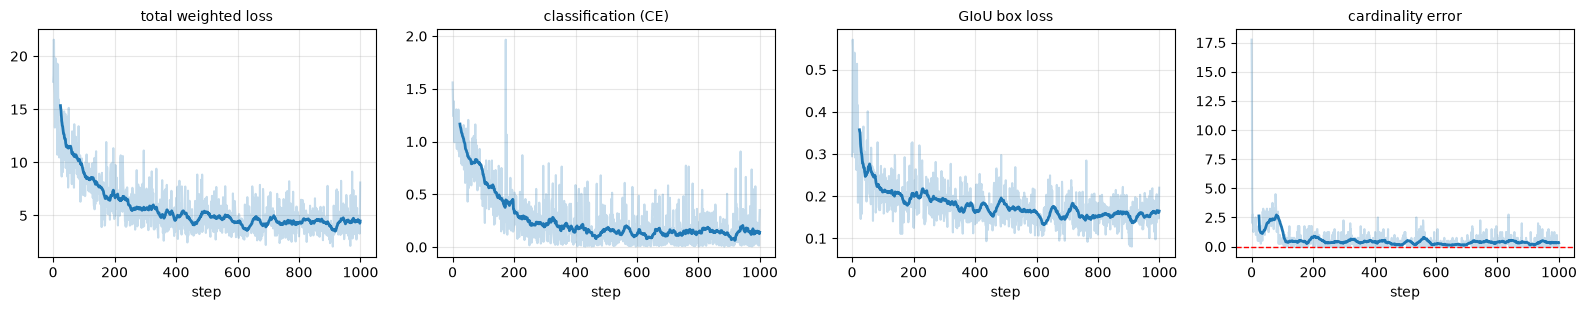

cardinality error  = |predicted #objects - true #objects|
  first 50 steps: 2.27
  last  50 steps: 0.33


In [9]:
def smooth(v, k=25):
    return np.convolve(v, np.ones(k)/k, mode="valid")

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, key, title in zip(axes,
                          ["loss", "ce", "giou", "card"],
                          ["total weighted loss", "classification (CE)",
                           "GIoU box loss", "cardinality error"]):
    v = [h[key] for h in history]
    ax.plot(v, alpha=.25, color="C0")
    ax.plot(range(len(v)-len(smooth(v)), len(v)), smooth(v), color="C0", lw=2)
    ax.set_title(title, fontsize=10); ax.set_xlabel("step"); ax.grid(alpha=.3)
axes[3].axhline(0, color="r", ls="--", lw=1)
plt.tight_layout(); plt.show()

print("cardinality error  = |predicted #objects - true #objects|")
print(f"  first 50 steps: {np.mean([h['card'] for h in history[:50]]):.2f}")
print(f"  last  50 steps: {np.mean([h['card'] for h in history[-50:]]):.2f}")

The **cardinality error** curve is the one to watch. It starts high (the random head labels almost every query as an object) and falls toward 0 — the model learning *how many* things are present. Remember this is logged only, never backpropagated (`@torch.no_grad()` in [`models/detr.py:129`](../models/detr.py#L129)).

## 6. Predictions after training

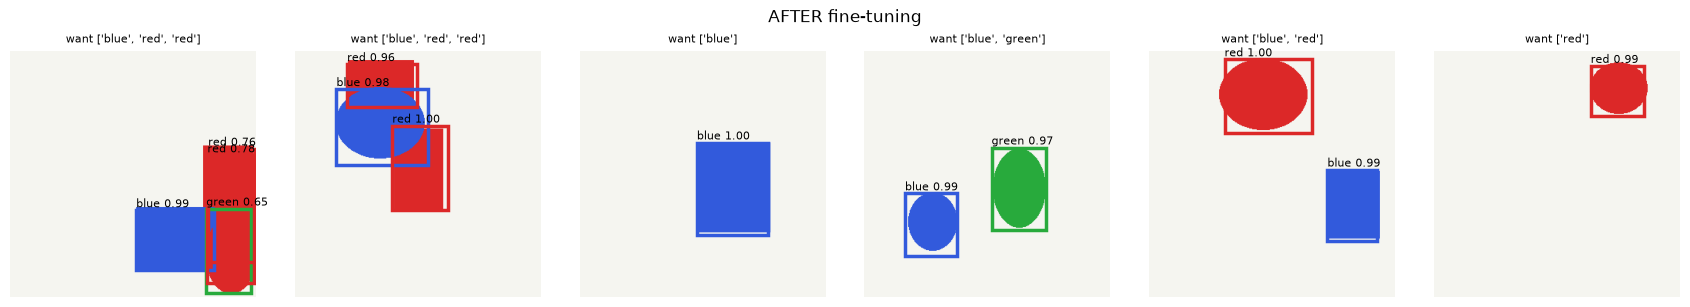

  img 0: want ['blue', 'red', 'red']       got ['blue', 'green', 'red', 'red'] x
  img 1: want ['blue', 'red', 'red']       got ['blue', 'red', 'red']       OK
  img 2: want ['blue']                     got ['blue']                     OK
  img 3: want ['blue', 'green']            got ['blue', 'green']            OK
  img 4: want ['blue', 'red']              got ['blue', 'red']              OK
  img 5: want ['red']                      got ['red']                      OK

5/6 images with an exactly correct set of detections


In [10]:
probs, boxes, keep = show(model, "AFTER fine-tuning")

exact = 0
for i, t in enumerate(eval_t):
    got = sorted(NAMES[c] for c in probs[i, keep[i], :-1].argmax(-1).tolist())
    want = sorted(NAMES[c] for c in t["labels"].tolist())
    exact += (got == want)
    print(f"  img {i}: want {str(want):<28} got {str(got):<28} {'OK' if got==want else 'x'}")
print(f"\n{exact}/6 images with an exactly correct set of detections")

Colours correct, boxes tight, counts right — from a model that 2 minutes ago had never seen a coloured rectangle. Remaining mistakes are usually on heavily-overlapping shapes, where the model either merges two objects into one or emits a spurious extra box.

Two honest caveats:
- 1000 steps is tiny. More steps keeps improving it.
- This is a toy distribution. Real fine-tuning needs real data, augmentation, and an eval protocol (COCO mAP via `pycocotools` — `uv sync --extra coco`).

## 7. Do auxiliary losses actually help? (testing a paper claim)

The paper claims aux losses especially help *"the model output the correct number of objects"* (§3.2). While writing this tutorial I ran the identical recipe both ways:

| Setting | Exactly-correct images | Failure mode |
|---|---|---|
| `aux_loss=False`, 1000 steps | **3 / 6** | duplicates — one image produced 6 boxes for 2 objects |
| `aux_loss=True`, 1000 steps | **5 / 6** | one spurious extra box on overlapping shapes |

Supervising all 6 decoder layers, not just the last, largely cleaned up the duplicate predictions — exactly the claim. (Your exact score will vary with the random seed; the *kind* of improvement is the reproducible part.) You can reproduce this by rebuilding with `aux_loss=False` and an unmodified `weight_dict`.

Why it works: each decoder layer is forced to produce a *valid complete set* on its own, so the duplicate-suppression job of query self-attention gets a training signal at every depth instead of only at the end.

## 8. Scaling up to a real dataset

To train on your own data instead of synthetic shapes, you need exactly two things:

1. **A `Dataset`** returning `(image_tensor, target_dict)` with `boxes` (normalized `cxcywh`) and `labels` (int64).
2. **`collate_fn=util.misc.collate_fn`** in your `DataLoader` — it builds the `NestedTensor` with padding masks from notebook `02`. Without it, variable-sized images won't batch.

```python
from torch.utils.data import DataLoader
from util.misc import collate_fn
loader = DataLoader(my_dataset, batch_size=4, collate_fn=collate_fn)
```

Then reuse the loop from §5. For the full-featured version — distributed training, LR schedule, COCO eval — read [`main.py`](../main.py) and [`engine.py`](../engine.py); everything there is now familiar.

**Set `num_classes` carefully.** It means `max_class_id + 1`, *not* the number of classes. See the comment at [`models/detr.py:304`](../models/detr.py#L304): COCO's ids run to 90, so DETR passes 91.

## You've finished the tutorial

| Notebook | What you learned |
|---|---|
| `01` | Detection as direct set prediction; no anchors, no NMS |
| `02` | Pixels → sequence; padding masks; positional encodings |
| `03` | Encoder, decoder, and what object queries really are |
| `04` | Hungarian matching — the idea that makes it all work |
| `05` | Encoder separates instances, decoder traces extremities |
| `06` | Fine-tuning on your own data |

### Where to go next

- **Deformable DETR** — fixes the slow convergence you felt in §5 and the weak small-object AP from notebook `02`
- **Panoptic segmentation** — [`models/segmentation.py`](../models/segmentation.py) in this repo; paper §4.4
- Re-read the paper. It should read very differently now.

### Try it yourself

- Add a 4th class (e.g. yellow). What has to change? (`NUM_CLASSES`, `PALETTE`, `NAMES` — and why does `class_embed` need rebuilding?)
- Make the task genuinely hard: class = **shape** (rectangle vs ellipse) with random colours. Does it still converge? What does that tell you about the 32×-downsampled feature grid from notebook `02`?
- Set `eos_coef=1.0` and retrain. Watch the cardinality error.
- Re-run notebook `05`'s attention hooks on *this* fine-tuned model. Does it attend to shape extremities the same way?